to understand the data we're dealing with , we first have to load the data , our main source of data was the website : http:/automobile.tn

we scraped all the new cars along with all the available used ones listed

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load data
df_new = pd.read_csv("../data_scraper/data_scraped/automobileTnNew.csv")

df_used = pd.read_csv("../data_scraper/data_scraped/automobileTnUsed.csv")


first let's check the structure/dimensions of the data we're dealing with along with some general informations 

In [3]:
print("=== NEW CARS DATASET ===")
print(f"Shape: {df_new.shape}")
print("\nInfo:")
print(df_new.info())
print("\nFirst few rows:")
print(df_new.head())

print("\n=== USED CARS DATASET ===")
print(f"Shape: {df_used.shape}")
print("\nInfo:")
print(df_used.info())
print("\nFirst few rows:")
print(df_used.head())

=== NEW CARS DATASET ===
Shape: (510, 166)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 510 entries, 0 to 509
Columns: 166 entries, URL to Cylindrée
dtypes: float64(33), int64(1), object(132)
memory usage: 661.5+ KB
None

First few rows:
                                                 URL  Brand   Model  \
0  https://www.automobile.tn/fr/neuf/skoda/fabia/...  skoda   fabia   
1  https://www.automobile.tn/fr/neuf/skoda/fabia/...  skoda   fabia   
2  https://www.automobile.tn/fr/neuf/skoda/fabia/...  skoda   fabia   
3  https://www.automobile.tn/fr/neuf/skoda/kushaq...  skoda  kushaq   
4  https://www.automobile.tn/fr/neuf/skoda/kushaq...  skoda  kushaq   

                  Option    Price Temps de recharge normale (AC) Peinture  \
0      1.0-l-mpi-essence  66 980                             NaN      NaN   
1    1.0-l-mpi-selection  72 980                             NaN      NaN   
2  1.0-l-mpi-monte-carlo  85 980                             NaN      NaN   
3       1.0-tsi

now we'll check for basic stats , column names , and missing values

In [6]:
# Check for missing values
print("\n=== MISSING VALUES ===")
print("New cars - Missing values:")
print(df_new.isnull().sum().sort_values(ascending=False))
print("\nUsed cars - Missing values:")
print(df_used.isnull().sum().sort_values(ascending=False))

# Basic statistics
print("\n=== BASIC STATISTICS ===")
print("New cars - Description:")
print(df_new.describe(include='all'))
print("\nUsed cars - Description:")
print(df_used.describe(include='all'))

# Check column names to understand what features you have
print("\n=== COLUMNS ===")
print("New cars columns:", df_new.columns.tolist())
print("Used cars columns:", df_used.columns.tolist())



=== MISSING VALUES ===
New cars - Missing values:
4 roues directrices            510
Voiture populaire              510
Anti-démarrage électronique    510
ABS                            510
Fixations ISOFIX               510
                              ... 
Energie                          0
Largeur                          0
Transmission                     0
Carrosserie                      0
URL                              0
Length: 166, dtype: int64

Used cars - Missing values:
État général                                    53
Anciens propriétaires                           39
URL                                              0
Intérieurs - Boîte à gants réfrigérée            0
Spécifications - Carrosserie                     0
                                                ..
Fonctionnels - Allumage automatique des feux     0
Extérieurs - Caméras 360                         0
Intérieurs - Accoudoir arrière                   0
Date de l'annonce                                0

we notice that in new cars data , there are various columns that lack data, we'll go back to that when we'll prepare the data , for the stats part there is a lot of information regarding all the columns that might overwhelm us so we'll stick to the main points : we notice that i'd need to convert the pricing of the new cars to a numeric format as it is currently in string format. as for used cars its showing this : mean: 93,730 TND, min: 1,111 TND, max: 720,000 TND

we notice again that Many columns in new cars dataset are almost empty , and that most columns have very few values



let's start little by little in visuqlizing the data in form of graphs, first met's focus on the used car ,  we'll have a look at brand and price distribtution , car body types , fuel types , transmission types and year distributions

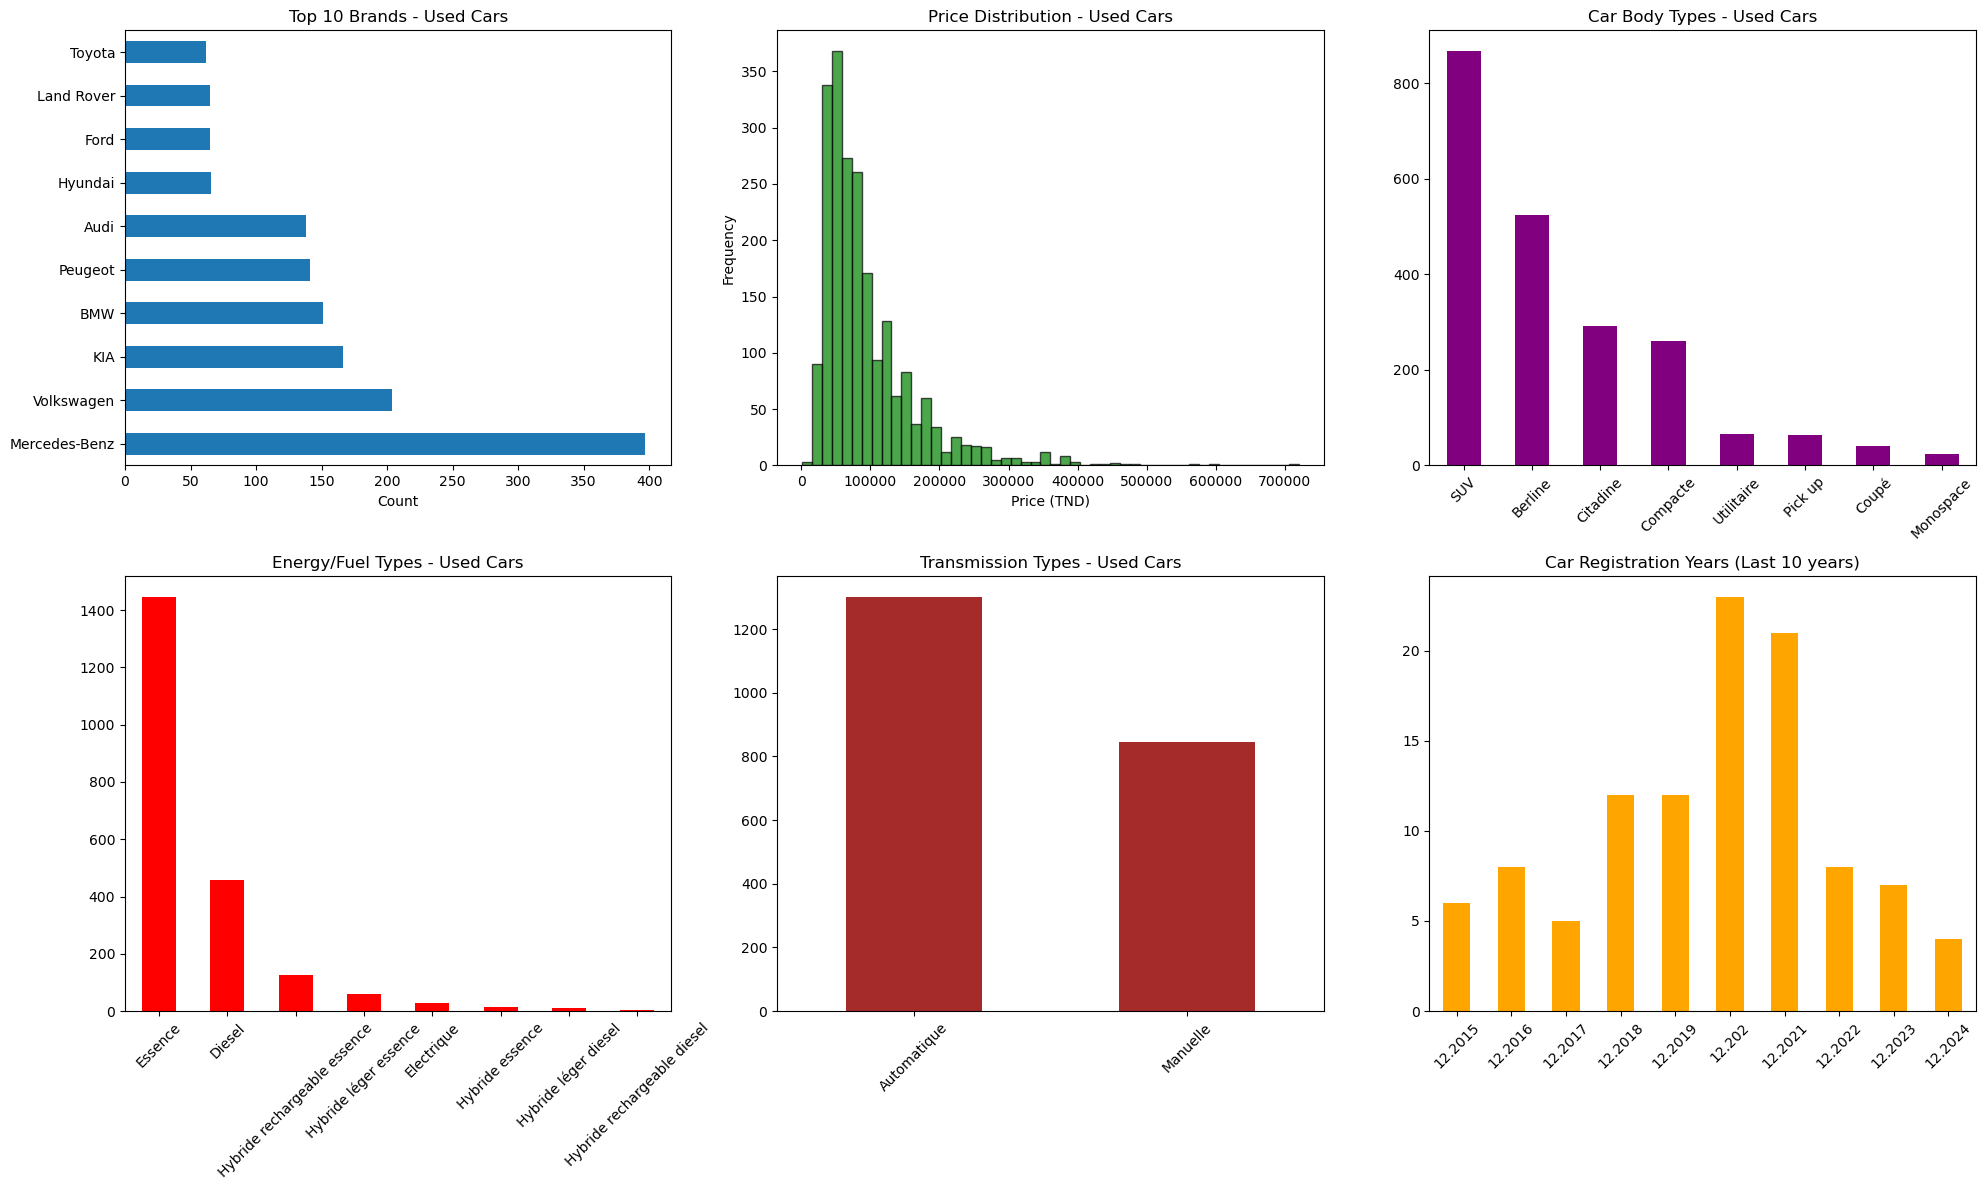

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# 1. Brand Distribution - Used Cars
plt.subplot(2, 3, 1)
brand_counts_used = df_used['Spécifications - Marque'].value_counts().head(10)
brand_counts_used.plot(kind='barh')
plt.title('Top 10 Brands - Used Cars')
plt.xlabel('Count')

# 2. Price Distribution - Used Cars
plt.subplot(2, 3, 2)
plt.hist(df_used['Price'], bins=50, alpha=0.7, edgecolor='black', color='green')
plt.title('Price Distribution - Used Cars')
plt.xlabel('Price (TND)')
plt.ylabel('Frequency')

# 3. Car Body Types - Used Cars
plt.subplot(2, 3, 3)
body_type_counts = df_used['Spécifications - Carrosserie'].value_counts().head(8)
body_type_counts.plot(kind='bar', color='purple')
plt.title('Car Body Types - Used Cars')
plt.xticks(rotation=45)

# 4. Energy/Fuel Types - Used Cars
plt.subplot(2, 3, 4)
energy_counts = df_used['Motorisation - Énergie'].value_counts().head(8)
energy_counts.plot(kind='bar', color='red')
plt.title('Energy/Fuel Types - Used Cars')
plt.xticks(rotation=45)

# 5. Transmission Types - Used Cars
plt.subplot(2, 3, 5)
transmission_counts = df_used['Boite vitesse'].value_counts().head(6)
transmission_counts.plot(kind='bar', color='brown')
plt.title('Transmission Types - Used Cars')
plt.xticks(rotation=45)

# 6. Year Distribution - Used Cars
plt.subplot(2, 3, 6)
if 'Mise en circulation' in df_used.columns:
    year_counts = df_used['Mise en circulation'].value_counts().sort_index().tail(10)
    year_counts.plot(kind='bar', color='orange')
    plt.title('Car Registration Years (Last 10 years)')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

now the same but for new cars

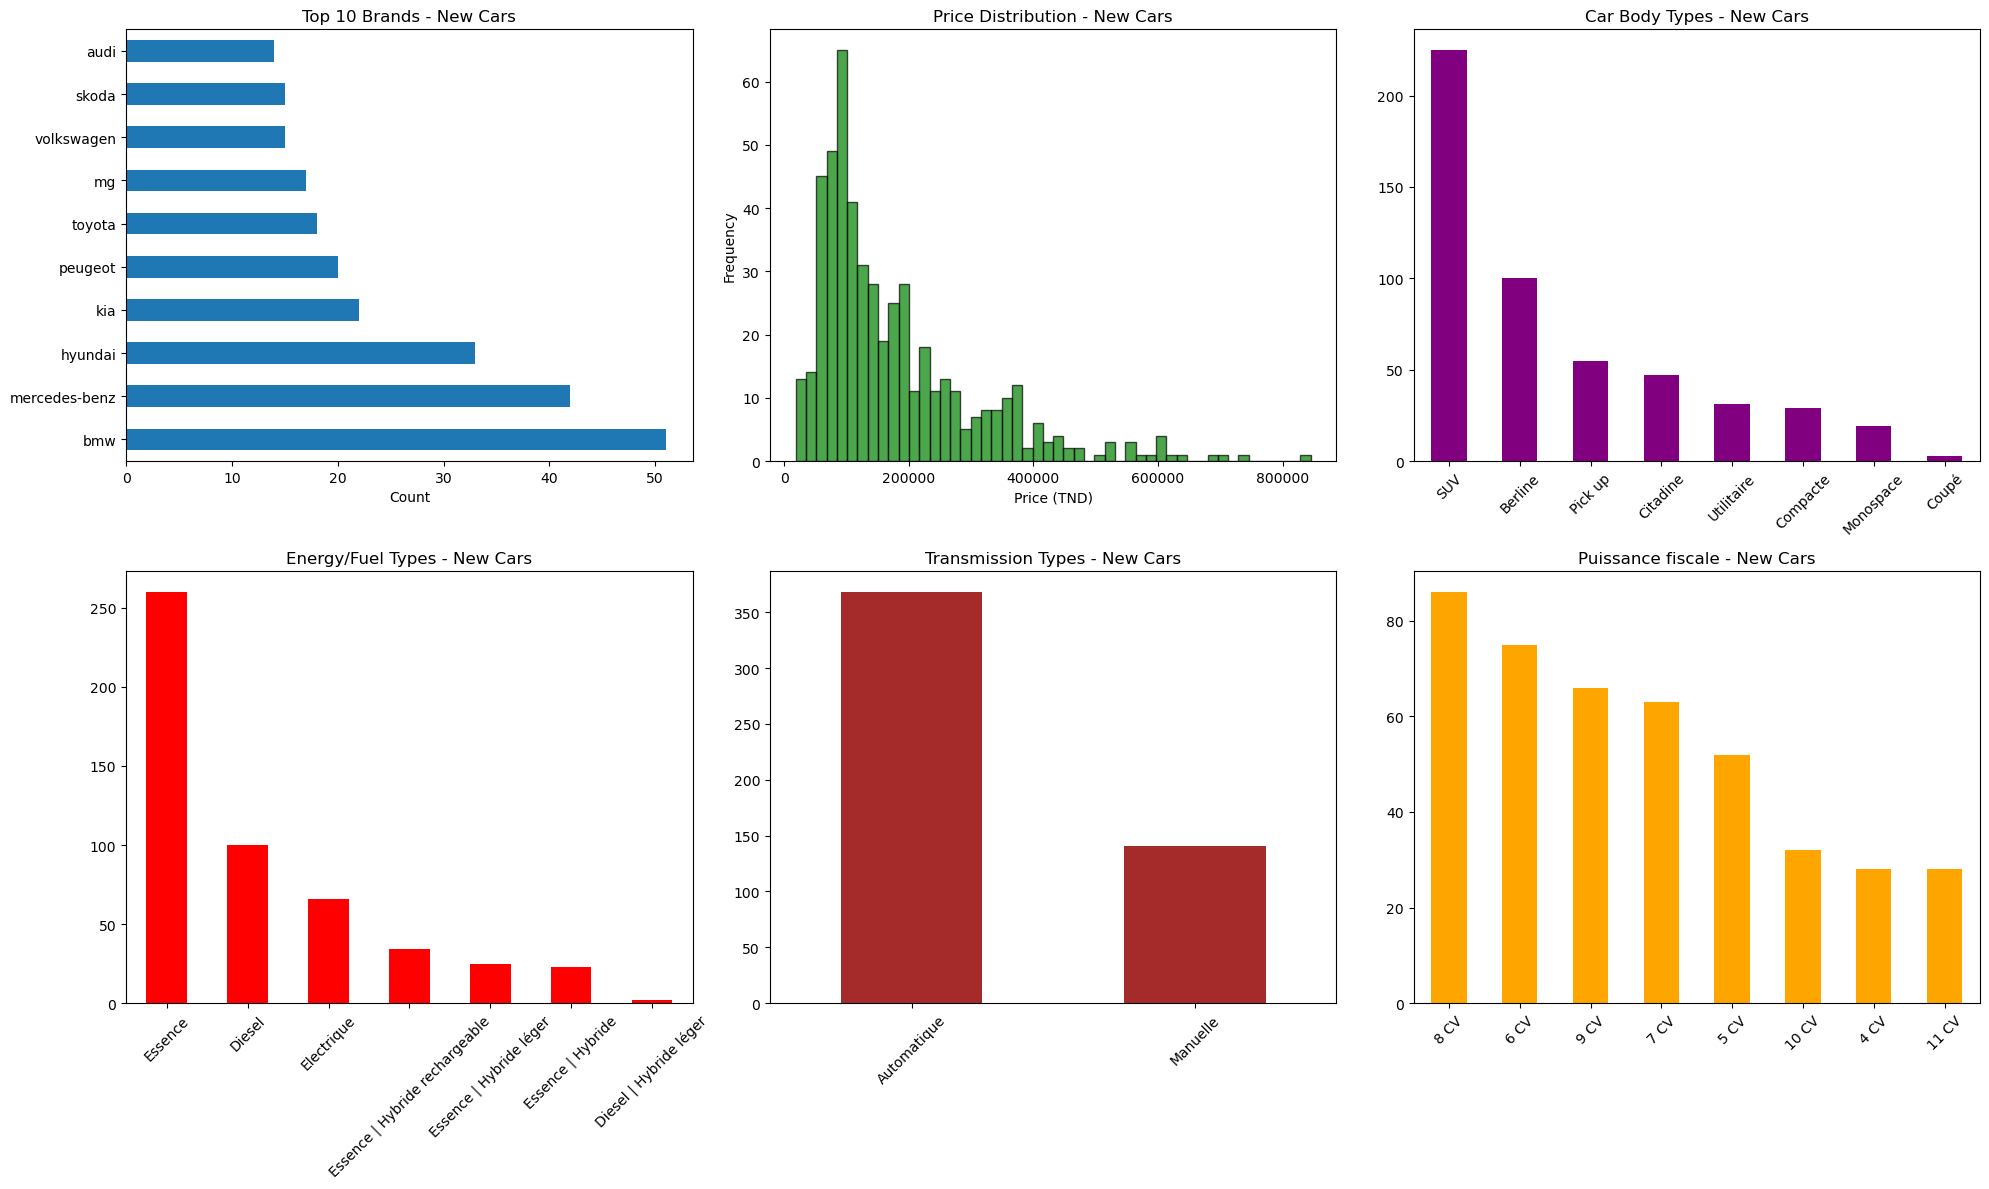

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# Convert price to float for new cars
df_new['Price_float'] = df_new['Price'].str.replace(' ', '').astype(float)

# 1. Brand Distribution - New Cars
plt.subplot(2, 3, 1)
brand_counts_new = df_new['Brand'].value_counts().head(10)
brand_counts_new.plot(kind='barh')
plt.title('Top 10 Brands - New Cars')
plt.xlabel('Count')

# 2. Price Distribution - New Cars (now as proper histogram)
plt.subplot(2, 3, 2)
plt.hist(df_new['Price_float'], bins=50, alpha=0.7, edgecolor='black', color='green')
plt.title('Price Distribution - New Cars')
plt.xlabel('Price (TND)')
plt.ylabel('Frequency')

# 3. Car Body Types - New Cars
plt.subplot(2, 3, 3)
body_type_counts_new = df_new['Carrosserie'].value_counts().head(8)
body_type_counts_new.plot(kind='bar', color='purple')
plt.title('Car Body Types - New Cars')
plt.xticks(rotation=45)

# 4. Energy/Fuel Types - New Cars
plt.subplot(2, 3, 4)
energy_counts_new = df_new['Energie'].value_counts().head(8)
energy_counts_new.plot(kind='bar', color='red')
plt.title('Energy/Fuel Types - New Cars')
plt.xticks(rotation=45)

# 5. Transmission Types - New Cars
plt.subplot(2, 3, 5)
transmission_counts_new = df_new['Boîte'].value_counts().head(6)
transmission_counts_new.plot(kind='bar', color='brown')
plt.title('Transmission Types - New Cars')
plt.xticks(rotation=45)

# 6. Puissance fiscale Distribution - New Cars 
plt.subplot(2, 3, 6)
if 'Puissance fiscale' in df_new.columns:
    cylinder_counts = df_new['Puissance fiscale'].value_counts().head(8)
    cylinder_counts.plot(kind='bar', color='orange')
    plt.title('Puissance fiscale - New Cars')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()